In [2]:
#Imports and config
import os
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt

import albumentations as A
from albumentations.pytorch import ToTensorV2

from torchvision.models.segmentation import deeplabv3_resnet50

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# Paths
DATA_ROOT = "/workspace/ML Main Large/Processed data"   # your folder

IMG_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 15

DEVICE: cuda


In [3]:
#Dataset loader
class RoadTrainDataset(Dataset):
    def __init__(self, root, transform=None):
        img_dir = os.path.join(root, "train/images")
        mask_dir = os.path.join(root, "train/masks")

        self.img_paths = sorted(glob(img_dir + "/*"))
        self.mask_paths = sorted(glob(mask_dir + "/*"))
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype("float32")

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img = aug["image"]
            mask = aug["mask"].unsqueeze(0)

        return img, mask

In [4]:
#transforms + dataloader
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=10, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.Normalize(),
    ToTensorV2()
])

train_ds = RoadTrainDataset(DATA_ROOT, transform=train_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

print("Train images:", len(train_ds))

Train images: 14688


In [5]:
#Model (DeepLabV3+)
def get_model():
    model = deeplabv3_resnet50(weights=None, num_classes=1)
    return model.to(DEVICE)

In [6]:
#Loss, IoU, Training Loop
bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1e-6
    inter = (pred * target).sum()
    union = pred.sum() + target.sum()
    return 1 - (2*inter + smooth) / (union + smooth)

def total_loss(pred, target):
    return 0.5 * bce(pred, target) + 0.5 * dice_loss(pred, target)

def iou(pred, mask):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * mask).sum()
    union = pred.sum() + mask.sum() - inter
    return (inter + 1e-6) / (union + 1e-6)

In [7]:
#Train Model
def train_deeplab():
    model = get_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(1, EPOCHS+1):
        model.train()
        t_loss = 0
        t_iou = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")

        for img, mask in pbar:
            img, mask = img.to(DEVICE), mask.to(DEVICE)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                out = model(img)["out"]  # DeepLab output
                loss = total_loss(out, mask)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            t_loss += loss.item()
            t_iou += iou(out, mask).item()

            pbar.set_postfix({"loss": t_loss/len(train_loader), "iou": t_iou/len(train_loader)})

        print(f"Train Loss: {t_loss/len(train_loader):.4f} | Train IoU: {t_iou/len(train_loader):.4f}")
        torch.save(model.state_dict(), "deeplab_best.pth")
        print("Saved model\n")

    print("Training complete.")

In [8]:
train_deeplab()

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass

poch 1/15: 100%|██████████| 3672/3672 [02:39<00:00, 22.98it/s, loss=0.352, iou=0.311]   

Train Loss: 0.3517 | Train IoU: 0.3105
Saved model




poch 2/15: 100%|██████████| 3672/3672 [02:35<00:00, 23.62it/s, loss=0.283, iou=0.386]   

Train Loss: 0.2827 | Train IoU: 0.3862
Saved model




poch 3/15: 100%|██████████| 3672/3672 [02:35<00:00, 23.65it/s, loss=0.27, iou=0.407]    

...

Train Loss: 0.2390 | Train IoU: 0.4586
Saved model




poch 14/15: 100%|██████████| 3672/3672 [02:36<00:00, 23.50it/s, loss=0.239, iou=0.458]   

Train Loss: 0.2394 | Train IoU: 0.4583
Saved model




poch 15/15: 100%|██████████| 3672/3672 [02:36<00:00, 23.46it/s, loss=0.238, iou=0.46]    

Train Loss: 0.2379 | Train IoU: 0.4601
Saved model

Training complete.


In [9]:
#prediction function (valid/test)
def predict_mask(model, img_path):
    img = cv2.imread(img_path)
    if img is None:
        print("Cannot read:", img_path)
        return None, None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    transform = A.Compose([
        A.Normalize(),
        ToTensorV2()
    ])

    aug = transform(image=img)
    img_t = aug["image"].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(img_t)["out"]
        pred = (torch.sigmoid(pred)[0,0].cpu().numpy() * 255).astype("uint8")

    pred = cv2.resize(pred, (w, h))
    return img, pred

In [10]:
#load trained model
def load_trained_model():
    model = get_model()
    model.load_state_dict(torch.load("deeplab_best.pth", map_location=DEVICE))
    model.eval()
    return model

model = load_trained_model()
print("Model loaded.")

Model loaded.


In [11]:
#Predict on TEST images
TEST_DIR = f"{DATA_ROOT}/test/images"
SAVE_TEST = "test_predictions_deeplab"
os.makedirs(SAVE_TEST, exist_ok=True)

files = sorted([f for f in os.listdir(TEST_DIR) if f.endswith((".jpg",".png"))])
print(f"Found {len(files)} test images.")

for f in files:
    img_path = os.path.join(TEST_DIR, f)
    img, mask = predict_mask(model, img_path)
    if mask is None: 
        continue
    cv2.imwrite(os.path.join(SAVE_TEST, f.replace(".jpg", "_mask.png")), mask)

print("Saved test predictions!")

Found 13082 test images.
Saved test predictions!


In [12]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 256   # Make sure it's the same you used in training

valid_transform = A.Compose([
    A.Normalize(),
    ToTensorV2()
])

In [13]:
#show predictions
import matplotlib.pyplot as plt
%matplotlib inline

def show_prediction(model, img_path):
    img, pred_mask = predict_mask(model, img_path)
    if pred_mask is None:
        return

    plt.figure(figsize=(15,5))

    # Original Image
    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(img)
    plt.axis("off")

    # Predicted Mask
    plt.subplot(1,3,2)
    plt.title("Predicted Mask")
    plt.imshow(pred_mask, cmap="gray")
    plt.axis("off")

    # Overlay
    overlay = img.copy()
    overlay[pred_mask > 127] = (0,255,0)

    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()

Showing: 15607_sat.jpg


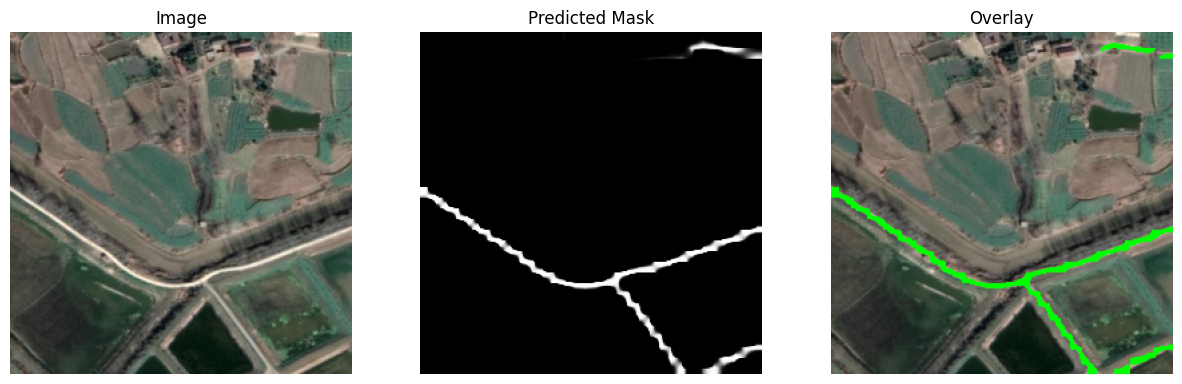

Showing: 15608_sat.jpg


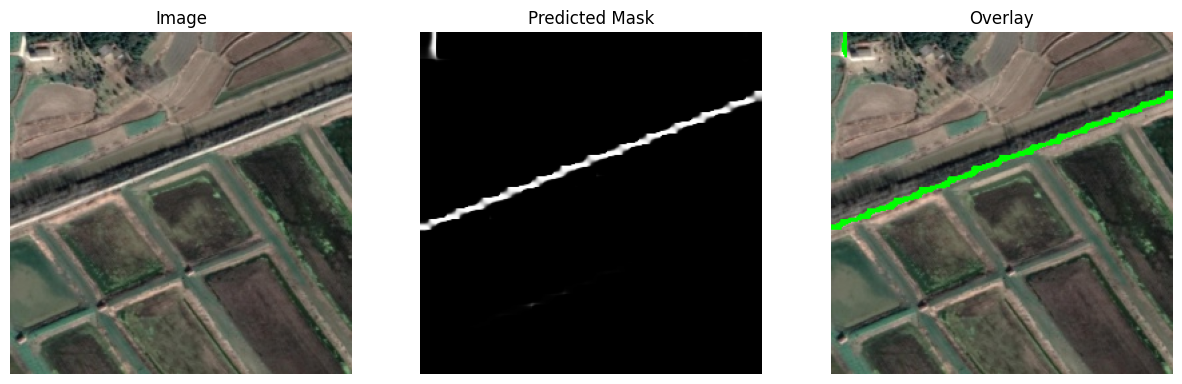

Showing: 15609_sat.jpg


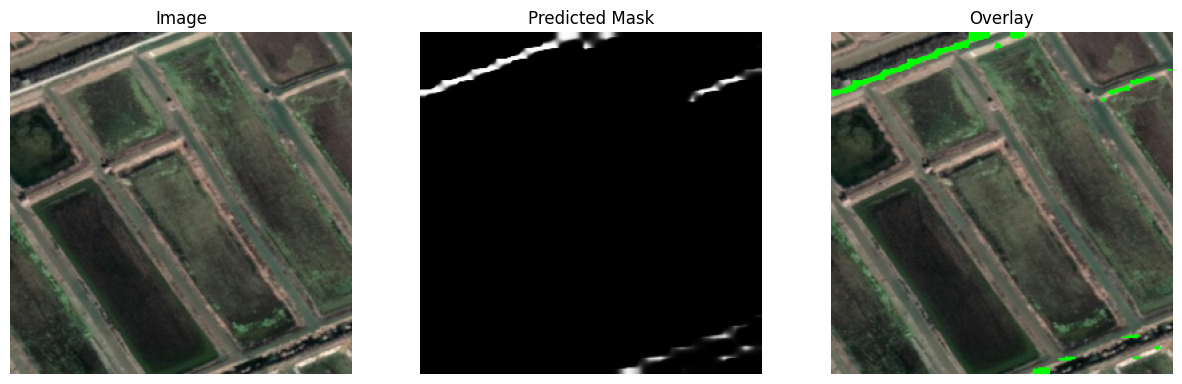

Showing: 15612_sat.jpg


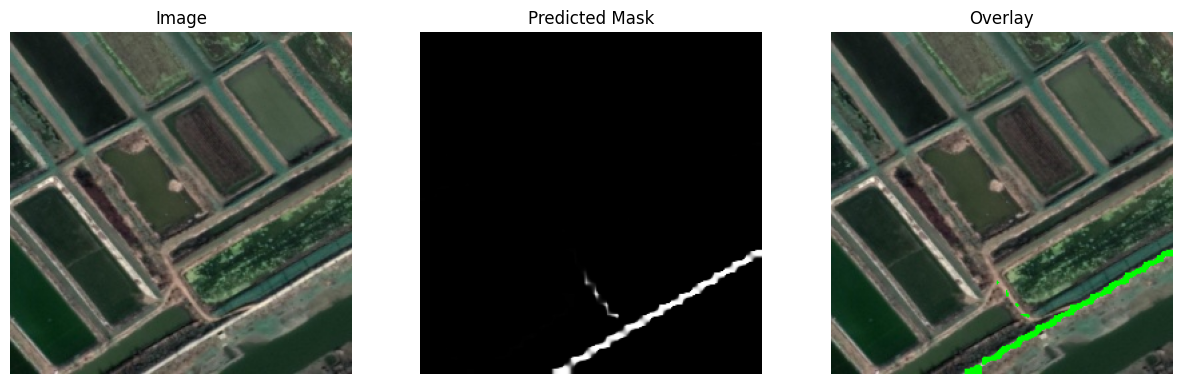

Showing: 15613_sat.jpg


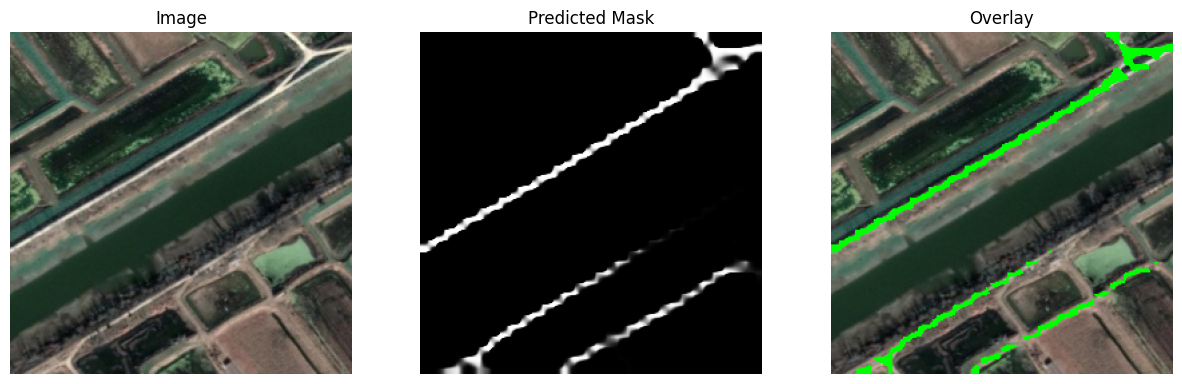

In [14]:
TEST_DIR = "/workspace/ML Main Large/Processed data/test/images"
files = sorted(os.listdir(TEST_DIR))

for f in files[:5]:
    print("Showing:", f)
    show_prediction(model, os.path.join(TEST_DIR, f))

In [15]:
#  EVALUATION FUNCTION FOR DEEPLABV3+
def evaluate_saved_model(model_path, dataset, batch_size=4):
    print(f"\nLoading saved model from: {model_path}")

    # Load model
    model = get_model()
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    total_loss_val = 0.0
    total_iou_val = 0.0
    count = 0

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Evaluating"):
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            # Forward pass
            with torch.cuda.amp.autocast():
                preds = model(imgs)["out"]
                loss = total_loss(preds, masks)

            total_loss_val += loss.item()

            # compute IoU for batch
            batch_iou = 0
            for i in range(preds.size(0)):
                batch_iou += iou(preds[i], masks[i]).item()

            total_iou_val += batch_iou
            count += preds.size(0)

    avg_loss = total_loss_val / len(loader)
    avg_iou = total_iou_val / count

    print("\nEVALUATION RESULTS")
    print(f"Average Loss : {avg_loss:.4f}")
    print(f"Average IoU  : {avg_iou:.4f}")

    return avg_loss, avg_iou

In [16]:
valid_ds = RoadTrainDataset(DATA_ROOT, transform=valid_transform)

evaluate_saved_model("deeplab_best.pth", valid_ds, batch_size=4)


Loading saved model from: deeplab_best.pth


Evaluating: 100%|██████████| 3672/3672 [03:49<00:00, 16.01it/s]


EVALUATION RESULTS
Average Loss : 0.2564
Average IoU  : 0.4600


(0.25642099145755237, 0.46003287126235737)